
# Why GNNs, Not MLPs?

Graph Neural Networks (GNNs) often beat plain Multi-Layer Perceptrons (MLPs)
when your data is about **connected things** — like who pays whom. This
notebook explains why, using one simple idea: **what actually feeds into the
activation function** in each type of network. Then we prove the point on a
small, hidden-fraud-ring example.

No advanced math here — just activation functions, simple averaging, and a
side-by-side comparison.



## 1. Quick reminder: what does an activation function do?

It takes a number (a neuron's weighted input) and turns it into the
neuron's output signal. Two common ones:

- **Sigmoid** squashes any number into the range (0, 1).
- **ReLU** keeps positive numbers as-is and zeroes out negative ones.


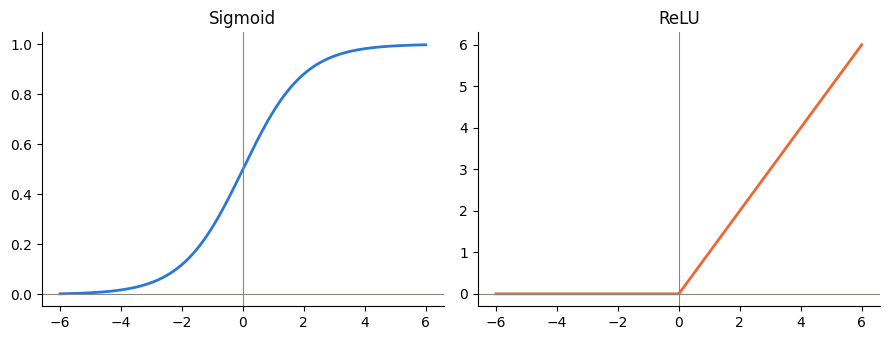

In [1]:

import numpy as np
import matplotlib.pyplot as plt

# a small, colorblind-checked palette used throughout
COLOR_MLP = "#2a78d6"    # blue   -> MLP
COLOR_GNN = "#eb6834"    # orange -> GNN
COLOR_NORMAL = "#2a78d6" # blue   -> normal account
COLOR_FRAUD = "#e34948"  # red    -> fraud ring account
COLOR_EDGE = "#9c9b95"
COLOR_TEXT = "#0b0b0b"
COLOR_MUTED = "#898781"

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def relu(z):
    return np.maximum(0, z)

z = np.linspace(-6, 6, 200)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].plot(z, sigmoid(z), color=COLOR_MLP, linewidth=2)
axes[0].set_title("Sigmoid", color=COLOR_TEXT)
axes[1].plot(z, relu(z), color=COLOR_GNN, linewidth=2)
axes[1].set_title("ReLU", color=COLOR_TEXT)
for ax in axes:
    ax.axhline(0, color=COLOR_MUTED, linewidth=0.8)
    ax.axvline(0, color=COLOR_MUTED, linewidth=0.8)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()



## 2. MLP neuron: the activation function only sees the node's OWN numbers

$$\text{activation}(w \cdot x + b), \qquad x = \text{this example's own features, and nothing else}$$


In [2]:

# Three accounts. B and C already look risky on their own; A looks fine.
own_risk = {"A": 0.2, "B": 0.9, "C": 0.8}

print("--- MLP view: activation(own score) ---")
for name, score in own_risk.items():
    out = relu(score)   # weight = 1, bias = 0, just to see the effect clearly
    print(f"  {name}: input to activation = {score:.2f}  ->  output = {out:.2f}")


--- MLP view: activation(own score) ---
  A: input to activation = 0.20  ->  output = 0.20
  B: input to activation = 0.90  ->  output = 0.90
  C: input to activation = 0.80  ->  output = 0.80



## 3. GNN node: the activation function sees the node's OWN numbers AND its neighbors'

Before applying the same activation function, a GNN first **averages in the
neighbors' numbers**. Same ReLU — a different, neighbor-aware input.


In [3]:

# A is connected to B and C (both risky). B and C are each connected to A.
neighbors = {"A": ["B", "C"], "B": ["A"], "C": ["A"]}

print("--- GNN view: activation( average(own score, neighbors' scores) ) ---")
for name in own_risk:
    values = [own_risk[name]] + [own_risk[nb] for nb in neighbors[name]]
    blended = sum(values) / len(values)
    out = relu(blended)
    print(f"  {name}: neighbors = {neighbors[name]}  ->  input to activation = {blended:.2f}  ->  output = {out:.2f}")

print("\nAccount A looked SAFE alone (0.20) but its GNN output jumps to 0.63")
print("once its risky neighbors are folded in -- same activation function,")
print("different input.")


--- GNN view: activation( average(own score, neighbors' scores) ) ---
  A: neighbors = ['B', 'C']  ->  input to activation = 0.63  ->  output = 0.63
  B: neighbors = ['A']  ->  input to activation = 0.55  ->  output = 0.55
  C: neighbors = ['A']  ->  input to activation = 0.50  ->  output = 0.50

Account A looked SAFE alone (0.20) but its GNN output jumps to 0.63
once its risky neighbors are folded in -- same activation function,
different input.



| | **MLP neuron** | **GNN node** |
|---|---|---|
| What feeds the activation function | only this node's own features | this node's own features + its neighbors' features |
| Sees who it's connected to? | no | yes |
| Same node, riskier neighbors → output changes? | no | yes |



## 4. Why this matters: catching a fraud ring

A fraud ring can make each account's *own* numbers look ordinary — but it
can't hide *who those accounts transact with*. Let's build a small
transaction network with a hidden ring, and see whether an MLP or a GNN
catches it.


In [4]:

import random
import networkx as nx

SEED = 7
random.seed(SEED)
np.random.seed(SEED)

N_NORMAL, N_RING = 37, 8
N = N_NORMAL + N_RING

G = nx.Graph()
G.add_nodes_from(range(N))
normal_nodes = list(range(N_NORMAL))
ring_nodes = list(range(N_NORMAL, N))          # the hidden fraud ring

# ordinary accounts: sparse, random connections
for i in range(len(normal_nodes)):
    for j in range(i + 1, len(normal_nodes)):
        if random.random() < 0.06:
            G.add_edge(normal_nodes[i], normal_nodes[j])

# the ring: a tight, densely-connected cluster (classic circular money movement)
for i in range(len(ring_nodes)):
    G.add_edge(ring_nodes[i], ring_nodes[(i + 1) % len(ring_nodes)])
for i in range(len(ring_nodes)):
    for j in range(i + 2, len(ring_nodes)):
        if random.random() < 0.55:
            G.add_edge(ring_nodes[i], ring_nodes[j])

# only 2 "bridge" edges connect the ring to the outside world
bridge_targets = random.sample(normal_nodes, 2)
G.add_edge(ring_nodes[0], bridge_targets[0])
G.add_edge(ring_nodes[3], bridge_targets[1])

for comp in list(nx.connected_components(G)):   # keep it connected, cosmetic only
    if ring_nodes[0] not in comp:
        G.add_edge(random.choice(normal_nodes), next(iter(comp)))

labels = np.array([1 if n in ring_nodes else 0 for n in G.nodes()])
print(f"Accounts: {N}   Fraud ring size: {N_RING}   Transactions (edges): {G.number_of_edges()}")


Accounts: 45   Fraud ring size: 8   Transactions (edges): 71


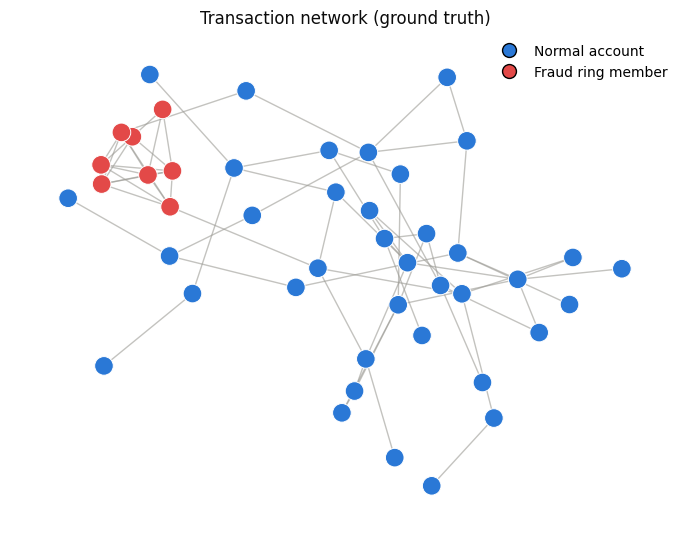

In [5]:

pos = nx.spring_layout(G, seed=SEED, k=0.45)
fig, ax = plt.subplots(figsize=(7, 5.5))
node_colors = [COLOR_FRAUD if labels[n] == 1 else COLOR_NORMAL for n in G.nodes()]
nx.draw_networkx_edges(G, pos, ax=ax, edge_color=COLOR_EDGE, width=1.0, alpha=0.6)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=180, edgecolors="white", linewidths=0.7)
ax.set_title("Transaction network (ground truth)", color=COLOR_TEXT)
ax.axis("off")
from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0], [0], marker="o", color="none", markerfacecolor=COLOR_NORMAL, markersize=10, label="Normal account"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor=COLOR_FRAUD, markersize=10, label="Fraud ring member"),
], loc="upper right", frameon=False)
plt.tight_layout()
plt.show()



Each account gets 3 simple numbers: typical transaction size, account age,
and how often it transacts at night. On purpose, these look **weak and
overlapping** between normal and fraud accounts — a ring trying to blend in.


In [6]:

import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.utils import from_networkx

torch.manual_seed(SEED)
rng = np.random.default_rng(SEED)

feat = np.zeros((N, 3))
for n in G.nodes():
    is_fraud = labels[n] == 1
    avg_amount = rng.normal(3200 if is_fraud else 2200, 2200)
    acct_age = rng.normal(420 if is_fraud else 650, 380)
    night_ratio = rng.beta(2.3, 3.0) if is_fraud else rng.beta(2, 3.5)
    feat[n] = [avg_amount, max(acct_age, 1), night_ratio]
feat = (feat - feat.mean(0)) / feat.std(0)   # standardize

for n in G.nodes():
    G.nodes[n]["x"] = feat[n].tolist()
data = from_networkx(G, group_node_attrs=["x"])
data.y = torch.tensor(labels, dtype=torch.long)
data.x = data.x.float()

idx = np.arange(N)
np.random.shuffle(idx)
train_mask = torch.zeros(N, dtype=torch.bool)
test_mask = torch.zeros(N, dtype=torch.bool)
train_mask[idx[:int(0.6 * N)]] = True
test_mask[idx[int(0.6 * N):]] = True

class_counts = np.bincount(labels[train_mask.numpy()])
class_weights = torch.tensor([1.0 / c for c in class_counts], dtype=torch.float)
print("Data ready:", int(train_mask.sum()), "training accounts,", int(test_mask.sum()), "test accounts.")


Data ready: 27 training accounts, 18 test accounts.



## 5. Train an MLP (sees only each account's own 3 numbers)


In [7]:

class MLPClassifier(torch.nn.Module):
    def __init__(self, in_dim, hidden, out_dim):
        super().__init__()
        self.fc1 = torch.nn.Linear(in_dim, hidden)
        self.fc2 = torch.nn.Linear(hidden, out_dim)
    def forward(self, x, edge_index=None):     # edge_index is ignored -- no graph info used
        return self.fc2(F.relu(self.fc1(x)))


def train_and_eval(model, epochs=200, lr=0.01):
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
    for _ in range(epochs):
        model.train(); opt.zero_grad()
        out = model(data.x, data.edge_index)
        loss = F.cross_entropy(out[train_mask], data.y[train_mask], weight=class_weights)
        loss.backward(); opt.step()
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        pred = out.argmax(dim=1)
        acc = (pred[test_mask] == data.y[test_mask]).float().mean().item()
        fraud_test = data.y[test_mask] == 1
        caught = (pred[test_mask][fraud_test] == 1).float().mean().item() if fraud_test.sum() > 0 else float("nan")
    return acc, caught, pred

torch.manual_seed(0)
mlp_acc, mlp_caught, mlp_pred = train_and_eval(MLPClassifier(3, 16, 2))
print(f"MLP accuracy: {mlp_acc:.2f}")
print(f"MLP: fraction of REAL fraud-ring accounts caught: {mlp_caught:.2f}")


MLP accuracy: 0.67
MLP: fraction of REAL fraud-ring accounts caught: 0.00



## 6. Train a GNN (sees each account's numbers AND the transaction network)

Same idea as Section 3: before the activation function runs, each account's
numbers get blended with its neighbors' numbers.


In [8]:

class GCNClassifier(torch.nn.Module):
    def __init__(self, in_dim, hidden, out_dim):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden)     # neighbor-aware layer
        self.conv2 = GCNConv(hidden, out_dim)
    def forward(self, x, edge_index):
        h = F.relu(self.conv1(x, edge_index))    # <- activation sees neighbor-blended input
        h = F.dropout(h, p=0.3, training=self.training)
        return self.conv2(h, edge_index)

torch.manual_seed(0)
gcn_acc, gcn_caught, gcn_pred = train_and_eval(GCNClassifier(3, 16, 2))
print(f"GNN accuracy: {gcn_acc:.2f}")
print(f"GNN: fraction of REAL fraud-ring accounts caught: {gcn_caught:.2f}")


GNN accuracy: 0.94
GNN: fraction of REAL fraud-ring accounts caught: 0.75


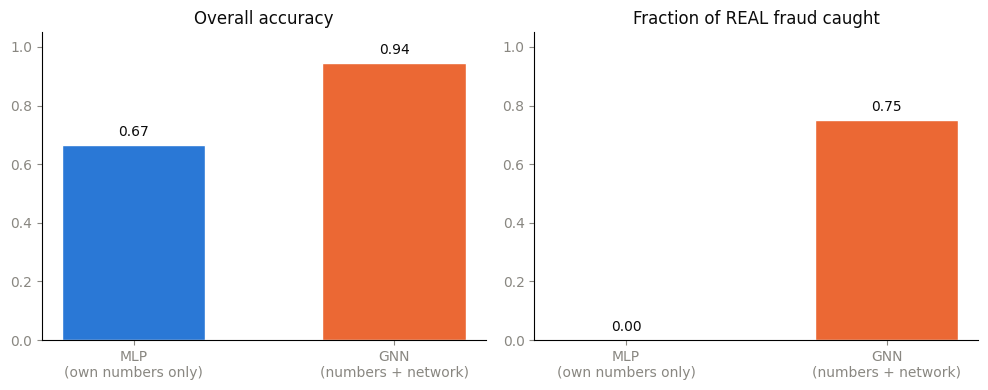

In [9]:

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
labels_x = ["MLP\n(own numbers only)", "GNN\n(numbers + network)"]

for ax, values, title in zip(
    axes,
    [[mlp_acc, gcn_acc], [mlp_caught, gcn_caught]],
    ["Overall accuracy", "Fraction of REAL fraud caught"],
):
    bars = ax.bar(labels_x, values, color=[COLOR_MLP, COLOR_GNN], width=0.55, edgecolor="white")
    ax.set_ylim(0, 1.05)
    ax.set_title(title, color=COLOR_TEXT)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.tick_params(colors=COLOR_MUTED)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.03, f"{v:.2f}", ha="center", color=COLOR_TEXT)

plt.tight_layout()
plt.show()



Below, only the **test accounts** (the ones each model never saw labels for)
are colored by prediction — training accounts are grayed out, so the picture
matches the "fraction caught" scores above.


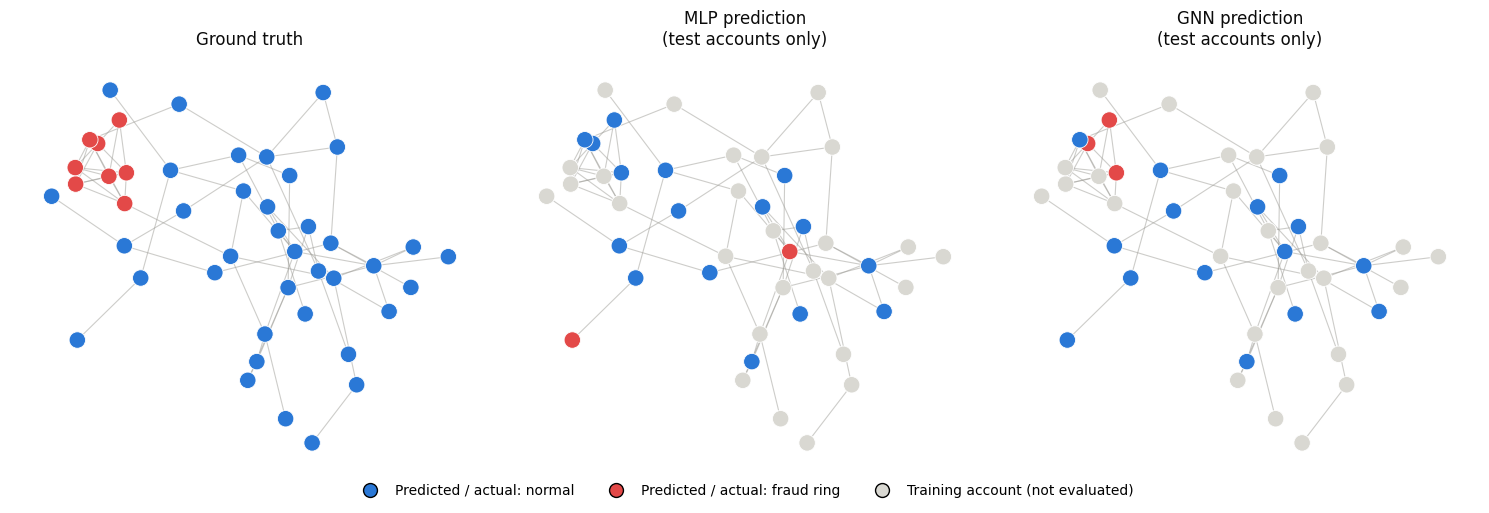

In [10]:

# For the prediction panels, only color TEST accounts by what the model predicted --
# training accounts are grayed out, since the model already saw their labels
# (coloring them too would make the MLP look better than its "fraction caught" score).
COLOR_TRAIN_DIM = "#d9d8d2"
test_mask_np = test_mask.numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, coloring, title, dim_train in zip(
    axes,
    [labels, mlp_pred.numpy(), gcn_pred.numpy()],
    ["Ground truth", "MLP prediction\n(test accounts only)", "GNN prediction\n(test accounts only)"],
    [False, True, True],
):
    if dim_train:
        node_colors = [
            (COLOR_FRAUD if coloring[n] == 1 else COLOR_NORMAL) if test_mask_np[n] else COLOR_TRAIN_DIM
            for n in G.nodes()
        ]
    else:
        node_colors = [COLOR_FRAUD if coloring[n] == 1 else COLOR_NORMAL for n in G.nodes()]
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color=COLOR_EDGE, width=0.8, alpha=0.5)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=140, edgecolors="white", linewidths=0.6)
    ax.set_title(title, color=COLOR_TEXT)
    ax.axis("off")

fig.legend(handles=[
    Line2D([0], [0], marker="o", color="none", markerfacecolor=COLOR_NORMAL, markersize=10, label="Predicted / actual: normal"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor=COLOR_FRAUD, markersize=10, label="Predicted / actual: fraud ring"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor=COLOR_TRAIN_DIM, markersize=10, label="Training account (not evaluated)"),
], loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.03))
plt.tight_layout()
plt.show()



## Why GNNs, not MLPs?

The MLP judged every account **alone** — so a ring built to look ordinary
on paper slipped right past it. The GNN's activation function saw each
account **plus its neighbors** — the same trick from Section 3 — so the
ring's tight cluster of connections gave it away, even though the accounts'
own numbers barely stood out.

**GNN advantages demonstrated here:**

- **Uses connections, not just features.** The activation input includes
  neighbor information; an MLP's never does.
- **Catches patterns that only exist in structure.** A fraud ring *is* a
  structural pattern (a tight, connected cluster) — invisible to a model
  that looks at accounts one at a time.
- **Measurably better on this task.** Compare the two bar charts above:
  same data, same features, only the model changed.
- **Same building blocks, smarter wiring.** A GNN doesn't use a different
  activation function than an MLP — it just feeds it richer, neighbor-aware
  input.
